# Regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mggp import MGGP

np.random.seed(42)

n_samples = 300
t = np.linspace(0, 20, n_samples)

u = (np.sin(t) + 0.25 * np.sin(3 * t)).reshape(-1, 1)

y = np.zeros((n_samples, 1))

for k in range(1, n_samples):
    y[k, 0] = 0.65 * y[k - 1, 0] + 0.35 * u[k, 0] + 0.10 * u[k, 0] * y[k - 1, 0]

split = int(0.70 * n_samples)
u_train, u_test = u[:split], u[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
mggp = MGGP(inputs=u_train,
            outputs=y_train,
            validation=(u_test, y_test),
            problem_type="regression",
            mode="NARX",
            evaluationMode="RMSE",
            evaluationType="MShooting",
            evaluationTypeTest="FreeRun",
            k=20,
            nDelays=1,
            generations=5,
            populationSize=30,
            nTerms=5,
            maxHeight=2,
            mutationRate=0.2,
            crossoverRate=0.9,
            elitePercentage=10,
            operators=["mul"],
            filename="best_mggp_regression.pkl",
)

mggp.run()

System Mode: SISO. N° Inputs: 1. N° Outputs: 1
Input Samples: 210. Output Samples: 210



Evaluating Initial Population: 100%|██████████| 30/30 [00:00<00:00, 126.77it/s]


   	     	          fitness          
   	     	---------------------------
gen	evals	min        	avg	max
1  	30   	1.05763e-15	inf	inf


Evaluating Population: 100%|██████████| 26/26 [00:00<00:00, 110.82it/s]


1
y1
u1
mul(y1, u1)
y1
q1(y1)

y1


...

3  	27   	1.01195e-15	inf	inf


Evaluating Population: 100%|██████████| 15/15 [00:00<00:00, 258.96it/s]


4  	15   	4.76886e-16	inf	inf


Evaluating Population: 100%|██████████| 26/26 [00:00<00:00, 486.63it/s]


5  	26   	4.76886e-16	inf	inf
-3.82695e-16 * 
3.60822e-16 * y1[k-2] * y1[k-2] +
3.50000e-01 * u1[k] +
-2.01228e-16 * y1[k-2] +
6.50000e-01 * y1[k-1] +
1.00000e-01 * u1[k] * y1[k-1] +
RMSE in validation dataset 2: 0.0
Executed in: 588.595 seg


In [4]:
best_model = mggp.load_model(r"models_saved\best_mggp_regression.pkl_0.pkl")

print("Identified equation:")
print(mggp.simplify_model(best_model))

Identified equation:
1.55280e-16 * 
1.66533e-15 * u1[k-1] +
3.50000e-01 * u1[k] +
6.50000e-01 * y1[k-1] +
1.00000e-01 * u1[k] * y1[k-1] +


Test RMSE: 0.000000


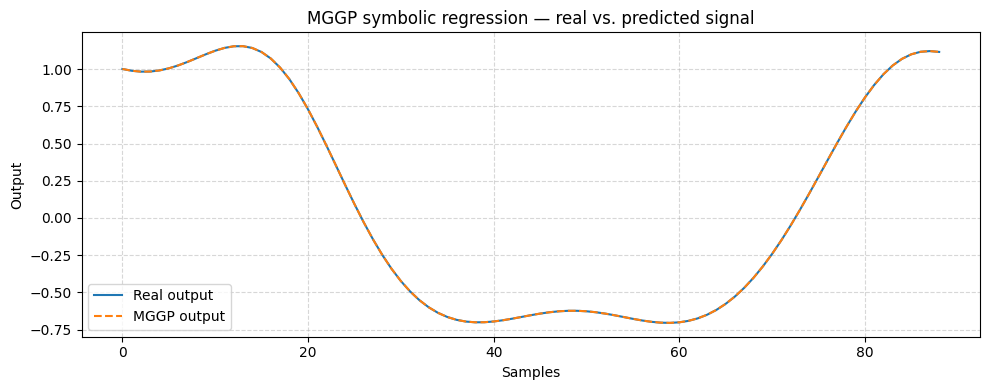

In [5]:
yp_test, yd_test = best_model.predict("FreeRun", y_test, u_test)
rmse = best_model.score(yd_test, yp_test, "RMSE")

print(f"Test RMSE: {rmse:.6f}")

plt.figure(figsize=(10, 4))
plt.plot(yd_test[:, 0], label="Real output")
plt.plot(yp_test[:, 0], "--", label="MGGP output")
plt.xlabel("Samples")
plt.ylabel("Output")
plt.title("MGGP symbolic regression — real vs. predicted signal")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# MultiObjective Regression

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mggp import MGGP

np.random.seed(42)

n_samples = 300
t = np.linspace(0, 20, n_samples)

u = (np.sin(t) + 0.25 * np.sin(3 * t)).reshape(-1, 1)

y = np.zeros((n_samples, 1))

for k in range(1, n_samples):
    y[k, 0] = 0.65 * y[k - 1, 0] + 0.35 * u[k, 0] + 0.10 * u[k, 0] * y[k - 1, 0]

split = int(0.70 * n_samples)
u_train, u_test = u[:split], u[split:]
y_train, y_test = y[:split], y[split:]

def count_times(individual, times_weight = 0.66):
    total_times_count = 0
    for gene in individual:

        str_gene = gene.__str__()
        times_count_gene = str_gene.count('mul') 
        times_count_gene = times_count_gene * times_weight
        total_times_count += times_count_gene

    return total_times_count

In [5]:
mggp = MGGP(inputs=u_train,
            outputs=y_train,
            validation=(u_test, y_test),
            problem_type="regression",
            mode="NARX",
            evaluationMode="RMSE",
            evaluationType="MShooting",
            evaluationTypeTest="FreeRun",
            k=20,
            nDelays=1,
            generations=5,
            populationSize=30,
            nTerms=5,
            maxHeight=2,
            mutationRate=0.2,
            crossoverRate=0.9,
            elitePercentage=10,
            operators=["mul"],
            new_evaluation=count_times
)

models = mggp.run()

System Mode: SISO. N° Inputs: 1. N° Outputs: 1
Input Samples: 210. Output Samples: 210



Evaluating Initial Population: 100%|██████████| 30/30 [00:00<00:00, 851.08it/s]


   	     	          fitness          
   	     	---------------------------
gen	evals	min     	avg	max
1  	30   	1.04e-15	inf	inf


Evaluating Population: 100%|██████████| 23/23 [00:00<00:00, 497.16it/s]


2  	23   	1.04e-15	inf	inf


...

3  	22   	1.04e-15	inf	inf


Evaluating Population: 100%|██████████| 26/26 [00:00<00:00, 692.87it/s]


4  	26   	1.04e-15	inf	inf


Evaluating Population: 100%|██████████| 26/26 [00:00<00:00, 734.89it/s]

5  	26   	1.04e-15	inf	inf
1.61820e-16 * 
1.00000e-01 * u1[k] * y1[k-1] +
3.50000e-01 * u1[k] +
6.50000e-01 * y1[k-1] +
-1.52656e-16 * y1[k-1] * y1[k-1] +
1.11022e-16 * y1[k-2] * y1[k-1] +
RMSE in validation dataset 2: 0.0
1.61820e-16 * 
1.00000e-01 * u1[k] * y1[k-1] +
3.50000e-01 * u1[k] +
6.50000e-01 * y1[k-1] +
-1.52656e-16 * y1[k-1] * y1[k-1] +
1.11022e-16 * y1[k-2] * y1[k-1] +
RMSE in validation dataset 2: 0.0
3.66632e-02 * 
7.64892e-01 * y1[k-1] +
4.33326e-01 * u1[k] +
-1.80791e-01 * u1[k-1] +
RMSE in validation dataset 2: 0.0769
3.73930e-03 * 
1.26469e-02 * u1[k-1] +
3.59496e-01 * u1[k] +
6.11669e-01 * y1[k-1] +
9.38828e-02 * y1[k-1] * y1[k-1] +
RMSE in validation dataset 2: 0.022537
4.21121e-16 * 
1.00000e-01 * y1[k-1] * u1[k] +
3.50000e-01 * u1[k] +
-5.82867e-16 * y1[k-2] +
1.66533e-16 * y1[k-1] * y1[k-1] +
6.50000e-01 * y1[k-1] +
RMSE in validation dataset 2: 0.0
Executed in: 0.293 seg


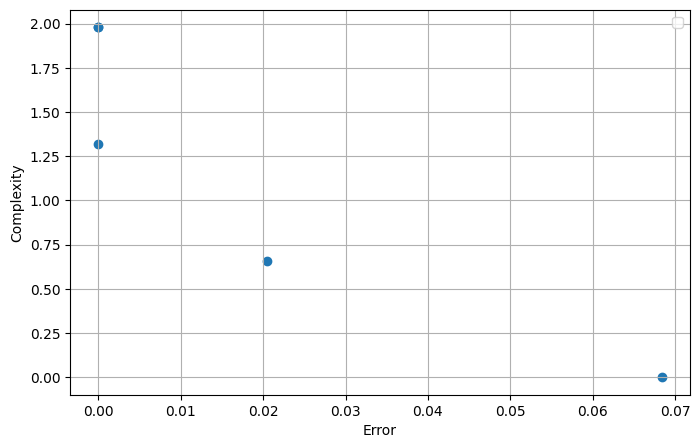

   Model         Error  Complexity
0      1  1.039996e-15        1.98
1      2  1.039996e-15        1.98
2      3  6.837691e-02        0.00
3      4  2.042577e-02        0.66
4      5  1.770821e-15        1.32


In [8]:
models[0].fitness
fitness = np.array([ind.fitness.values for ind in models])

plt.figure(figsize=(8, 5))
plt.scatter(fitness[:, 0], fitness[:, 1])
plt.xlabel("Error")
plt.ylabel("Complexity")
plt.legend()
plt.grid()
plt.show()

data = pd.DataFrame({
    'Model': [i+1 for i in range(len(models))],
    'Error': fitness[:, 0],
    'Complexity': fitness[:, 1],
})

print(data)

# Classification

In [5]:
import numpy as np
from mggp import MGGP

np.random.seed(42)
rng = np.random.default_rng(42)

n_samples = 300
X = rng.uniform(-1, 1, size=(n_samples, 2))

s = X[:, 0] + X[:, 1]
y_labels = np.zeros(n_samples, dtype=int)
y_labels[s > 0.5] = 2
y_labels[(s >= -0.5) & (s <= 0.5)] = 1

n_classes = 3
Y = np.eye(n_classes)[y_labels]

idx = rng.permutation(n_samples)
train_size = int(0.80 * n_samples)
train_idx = idx[:train_size]
test_idx = idx[train_size:]

X_train, X_test = X[train_idx], X[test_idx]
Y_train, Y_test = Y[train_idx], Y[test_idx]

In [6]:
mggp = MGGP(inputs=X_train,
            outputs=Y_train,
            validation=(X_test, Y_test),
            problem_type="classification",
            classification_metric="accuracy",
            mode="FIR",
            evaluationType="INSTANT",
            evaluationTypeTest="INSTANT",
            nDelays=1,
            k=1,
            generations=5,
            populationSize=30,
            nTerms=6,
            maxHeight=2,
            mutationRate=0.2,
            crossoverRate=0.9,
            elitePercentage=10,
            operators=["mul"],
            filename="best_mggp_classifier.pkl",
)

mggp.run()

System Mode: FIR. N° Inputs: 2. N° Outputs: 3
Input Samples: 240. Output Samples: 240



Evaluating Initial Population: 100%|██████████| 30/30 [00:00<00:00, 238.55it/s]


   	     	            fitness            
   	     	-------------------------------
gen	evals	min     	avg    	max    
1  	30   	0.041841	0.11042	0.27451


Evaluating Population: 100%|██████████| 23/23 [00:00<00:00, 241.55it/s]


2  	23   	0.0392157	0.10013	0.263305


...

3  	22   	0.0336134	0.068806	0.173669


Evaluating Population: 100%|██████████| 26/26 [00:00<00:00, 238.99it/s]


4  	26   	0.0280112	0.0547391	0.092437


Evaluating Population: 100%|██████████| 26/26 [00:00<00:00, 158.40it/s]


5  	26   	0.0280112	0.0509179	0.122734
Output 1:
2.28724e-01 * 
-5.11180e-01 * u1[k] +
4.11911e-01 * u2[k] * u2[k] * u1[k] +
5.92781e-02 * u1[k-1] +
-4.67605e-01 * u2[k] +
1.78701e-01 * u1[k-1] * u1[k-1] +
Output 2:
5.59953e-01 * 
-2.72496e-03 * u2[k] +
-4.86901e-02 * u2[k-2] +
-3.18587e-01 * u1[k] * u1[k] +
-2.19767e-02 * u1[k] +
-1.02813e+00 * u2[k] * u1[k] +
Output 3:
2.84758e-01 * 
4.77110e-01 * u1[k] +
3.63570e-01 * u2[k] +
Accuracy in validation dataset 2: 0.908046
F1-Score (macro) in validation dataset 2: 0.864111
Executed in: 5.53 seg


In [7]:
def sample_accuracy(y_true_onehot, y_pred_onehot):
    true_labels = np.argmax(y_true_onehot, axis=1)
    pred_labels = np.argmax(y_pred_onehot, axis=1)
    return np.mean(true_labels == pred_labels)

best_model = mggp.load_model("best_mggp_classifier.pkl")
best_model.logistic_model = True

Y_pred, Y_true = best_model.predict_classes("INSTANT", Y_test, X_test)
acc = sample_accuracy(Y_true, Y_pred)

print(f"Test accuracy: {acc:.4f}")
print("Identified classifier equations:")
print(mggp.simplify_model(best_model))

Test accuracy: 0.8621
Identified classifier equations:
Output 1:
2.28724e-01 * 
-5.11180e-01 * u1[k] +
4.11911e-01 * u2[k] * u2[k] * u1[k] +
5.92781e-02 * u1[k-1] +
-4.67605e-01 * u2[k] +
1.78701e-01 * u1[k-1] * u1[k-1] +
Output 2:
5.59953e-01 * 
-2.72496e-03 * u2[k] +
-4.86901e-02 * u2[k-2] +
-3.18587e-01 * u1[k] * u1[k] +
-2.19767e-02 * u1[k] +
-1.02813e+00 * u2[k] * u1[k] +
Output 3:
2.84758e-01 * 
4.77110e-01 * u1[k] +
3.63570e-01 * u2[k] +
